In [1]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

import sys
import os
c_directory = os.getcwd()
sys.path.append(os.path.dirname(c_directory))
sys.path.append(os.path.join(os.path.dirname(c_directory), 'FCYeast'))

import architecture
import FCYeast_simulator
import torch
import eZplot

device='cpu'
l10 = np.log(10)

/home/pessoa/Codes/SBI-Final/FC-inference/FCYeast/FCYeast_simulator.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  autofluo.load_state_dict(torch.load('autofluorescenc

In [2]:
# Define target
FCYeast_simulator.adjust_device(device)
target = FCYeast_simulator.target()

model = architecture.make_model().to(device)
model.load_state_dict(torch.load('network.pt'))


/tmp/ipykernel_58722/218563205.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('network.pt'))


<All keys matched successfully>

In [3]:
samples,gts =[],[]
for i in (48,33,42):
    g3 = np.loadtxt('FCYeast_MCMC/results_42seed_{}data_4096dp.csv'.format(i))#[:,:]
    # map_index = np.argmax(g3[:,-1])
    # best_param = torch.tensor(g3[map_index,:-1]).float().to(device)

    gt = np.loadtxt('FCYeast_synth/gt_map.csv')
    gt = gt[gt[:,0]==i,1:].reshape(-1)
    # best_param,gt
    samples.append(g3)
    gts.append(gt)

gts


[array([13.05150032, -2.0796001 ,  0.66280001, -1.91110003]),
 array([13.59459972, -1.19990003,  0.82620001, -2.50690007]),
 array([11.01010036, -0.93559998,  1.11720002, -2.12730002])]

In [4]:
def make_mcmc_figure(post_samples,gt):
    fig, ax = plt.subplots(1,4,figsize=(8,2.5))
    make_mcmc_plot(ax.reshape(-1),post_samples,gt)
    fig.tight_layout()
    return fig

def make_mcmc_plot(ax,post_samples,gt,xlabel=True):
    labs = [r'$\alpha (\bar{T}^{-1})$',r'$\lambda_{act} (\bar{T}^{-1})$',r'$\lambda_{ina} (\bar{T}^{-1})$',r'$\sigma$']
    first = True
    for post,gti,axi,lab in zip(post_samples.T/l10,gt/l10,ax,labs):
        
        axi.hist(post,density=True)
        if xlabel:
            axi.set_xlabel(r'$\log_{10}$'+(lab),fontsize=14)
        if xlabel and first:
            axi.axvline(gti,color='red',linestyle='dashed',label='Ground Truth')
        else:
            axi.axvline(gti,color='red',linestyle='dashed')

        first=False

    

[13.05150032 -2.0796001   0.66280001 -1.91110003]
[13.59459972 -1.19990003  0.82620001 -2.50690007]
[11.01010036 -0.93559998  1.11720002 -2.12730002]


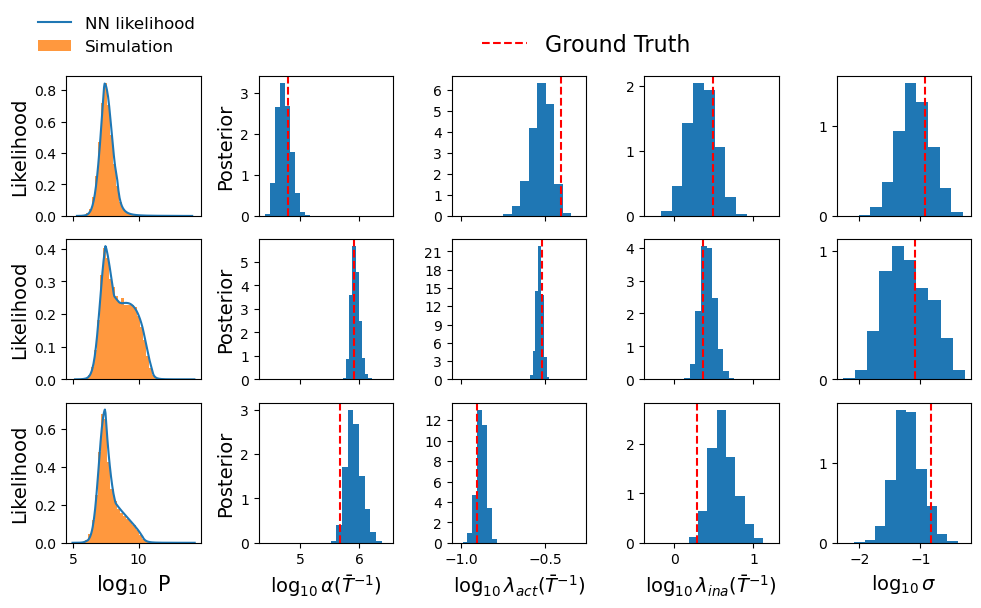

In [5]:
fig, ax = plt.subplots(3,5,figsize=(10,2.*3),sharex='col')


first = True
for axi,thi,sam in zip(reversed(ax),gts,samples):
    print(thi)
    eZplot.make_plot(axi[0],torch.tensor(thi).float(),model,target,legend=first)
    axi[0].set_ylabel(r'Likelihood',fontsize=14)    
    make_mcmc_plot(axi[1:],sam,thi,xlabel=first)
    axi[1].set_ylabel(r'Posterior',fontsize=14) 
    first = False
ax[-1,0].set_xlabel(r'$\log_{10}$ P',fontsize=15)
ax[-1,0].get_legend().remove()

handles1, labels1 = ax[-1, 0].get_legend_handles_labels()
fig.legend(handles1, labels1, loc='upper center', bbox_to_anchor=(0.13, 1.02), ncol=1, frameon=False,fontsize=12)

# Second figure-wide legend: Handles from one of the other subplots
handles2, labels2 = ax[-1, 1].get_legend_handles_labels()
fig.legend(handles2, labels2, loc='upper center', bbox_to_anchor=(0.6, 1.0), ncol=1, frameon=False,fontsize=16)

for axi in ax[:,1:].flatten():
    axi.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

fig.tight_layout(rect=[0, 0, 1, 0.92]) 
fig.savefig('panelbc',dpi=500)

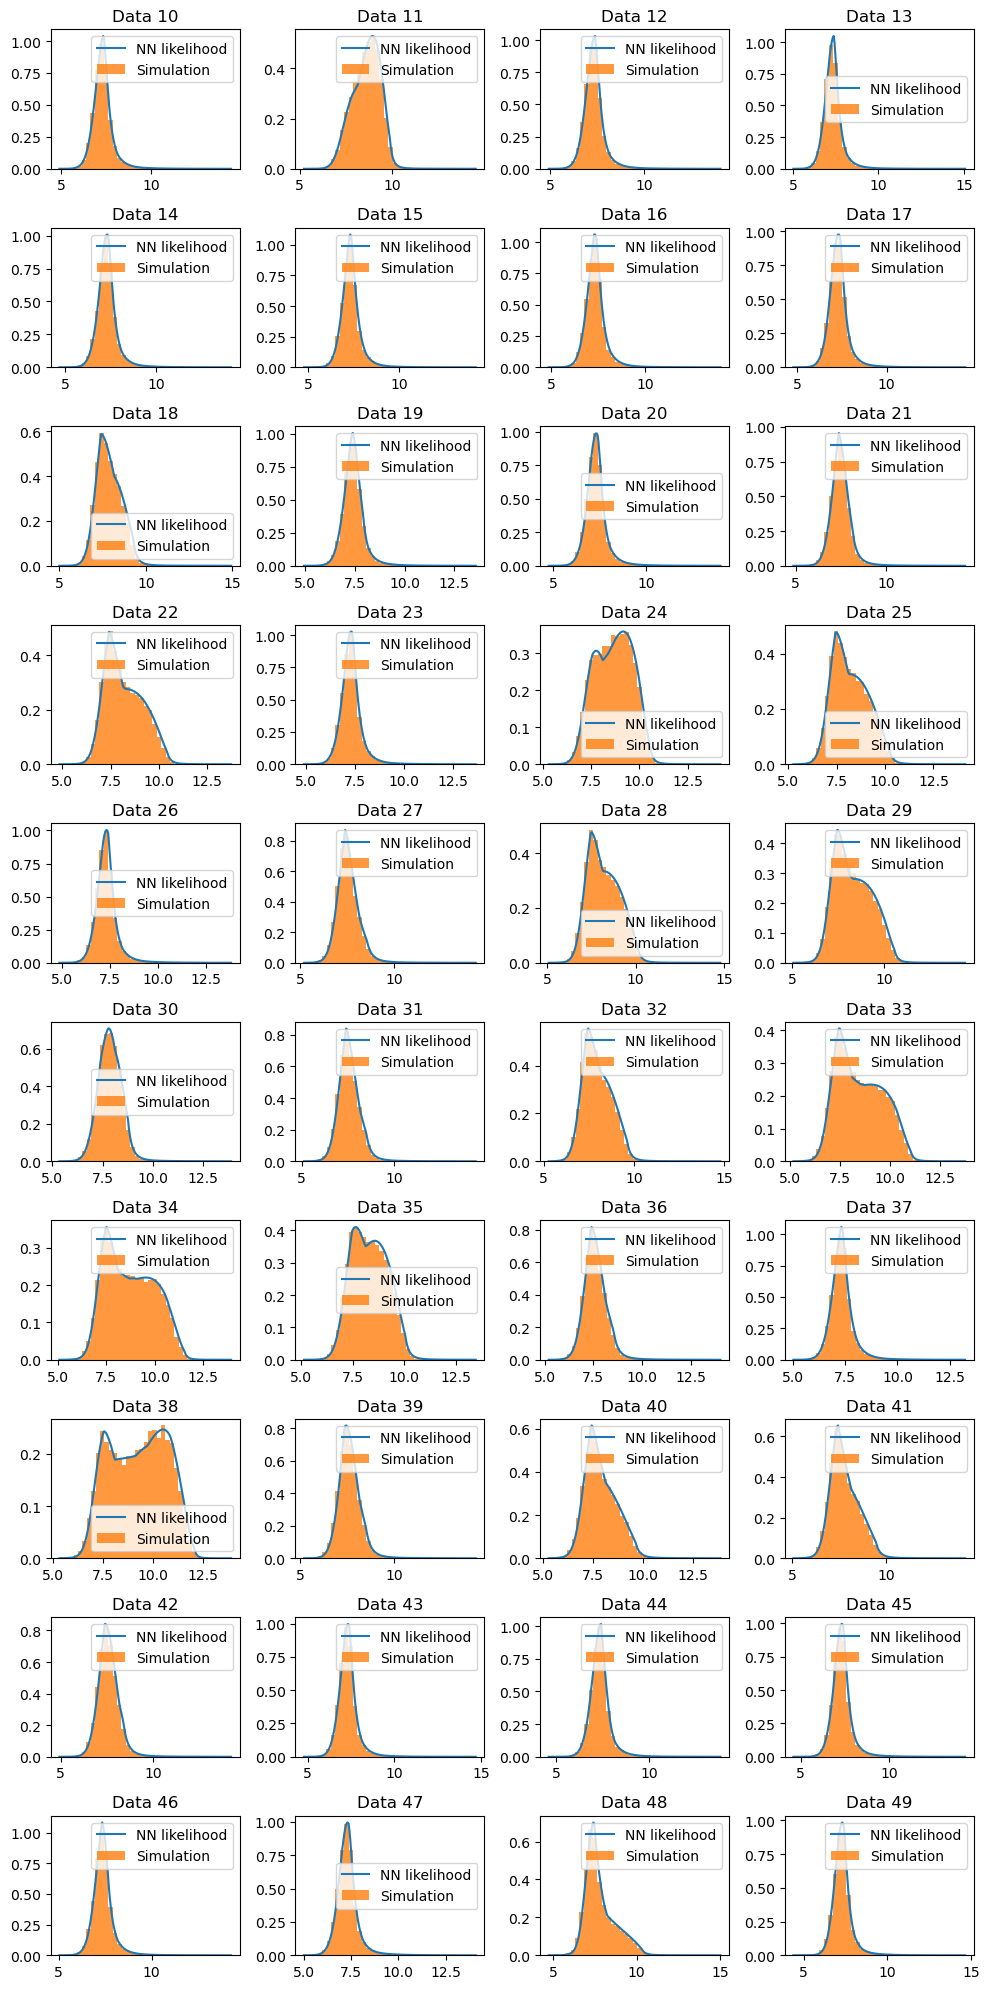

In [6]:
fig, ax = plt.subplots(10,4,figsize=(10,2.*10))


first = True
axflat = ax.reshape(-1)
gt = np.loadtxt('FCYeast_synth/gt_map.csv')
for i in range(40):
    thi = gt[gt[:,0]==i+10,1:].reshape(-1)
    eZplot.make_plot(axflat[i],torch.tensor(thi).float(),model,target,legend=first)
    axflat[i].set_title('Data {}'.format(i+10))
plt.tight_layout()